<a href="https://colab.research.google.com/github/Aman2125/DataScience_CampusX_Practice/blob/main/15)aman_seaborn_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import seaborn as sns

In [4]:
# import datasets
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

## Categorical Plots

### Categorical Scatter Plot

- Stripplot
- Swarmplot

### Categorical Distribution Plots

- Boxplot
- Violinplot

### Categorical Estimate Plot -> for central tendency

- Barplot
- Pointplot
- Countplot

### Figure level function -> `catplot`

<Axes: xlabel='total_bill', ylabel='tip'>

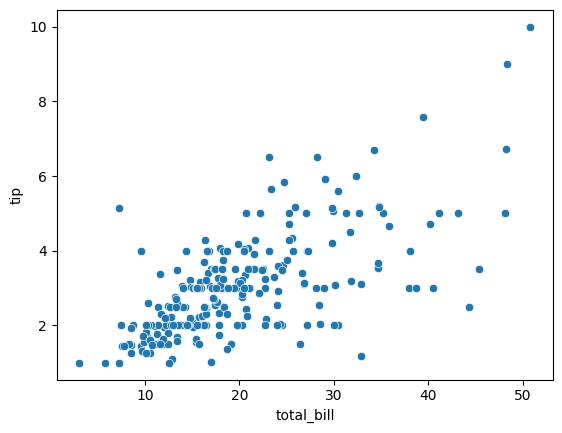

In [5]:
sns.scatterplot(data=tips , x='total_bill' , y='tip')

<Axes: xlabel='day', ylabel='total_bill'>

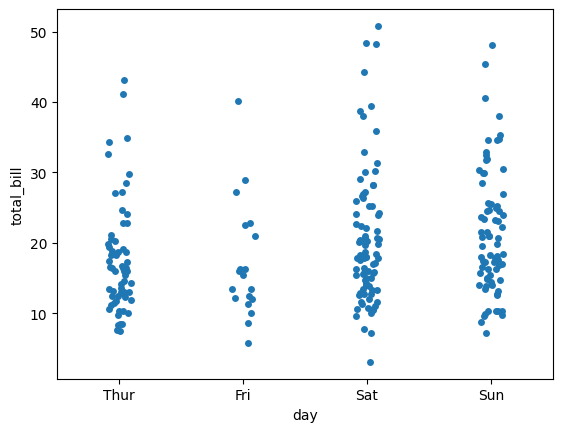

In [6]:
# strip plot , it is axes level func
sns.stripplot(data=tips , x='day' , y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

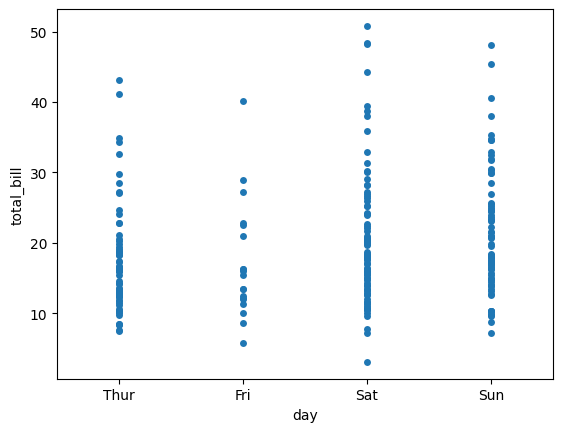

In [7]:
sns.stripplot(data=tips , x='day' , y='total_bill' , jitter=False)
# jitter used to bring all the points in one line as sns add some noise

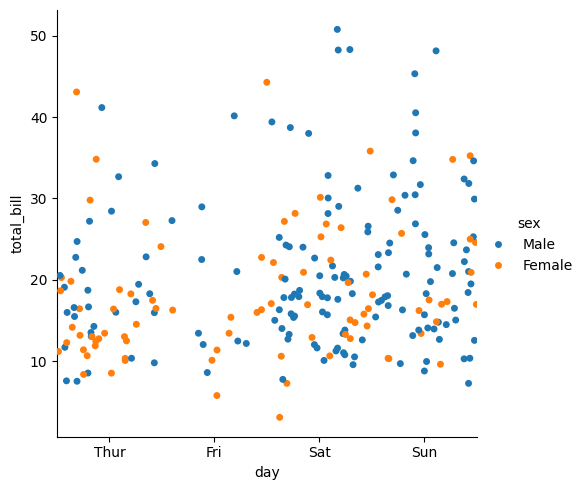

In [8]:
# using catplot , figure level func
sns.catplot(data=tips , x='day' , y='total_bill' , kind='strip' , jitter=0.5 , hue='sex')

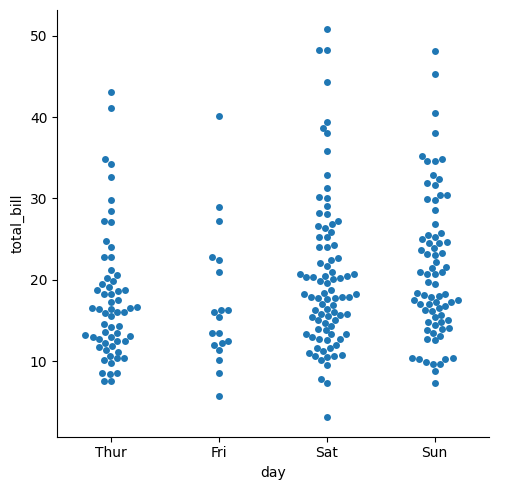

In [10]:
# swarmplot , represents the distribution of data in low level
sns.catplot(data=tips , x='day' , y='total_bill' , kind='swarm') #fig level

### Boxplot

A boxplot is a standardized way of displaying the distribution of data based on a five number summary (“minimum”, first quartile [Q1], median, third quartile [Q3] and “maximum”). It can tell you about your outliers and what their values are. Boxplots can also tell you if your data is symmetrical, how tightly your data is grouped and if and how your data is skewed.

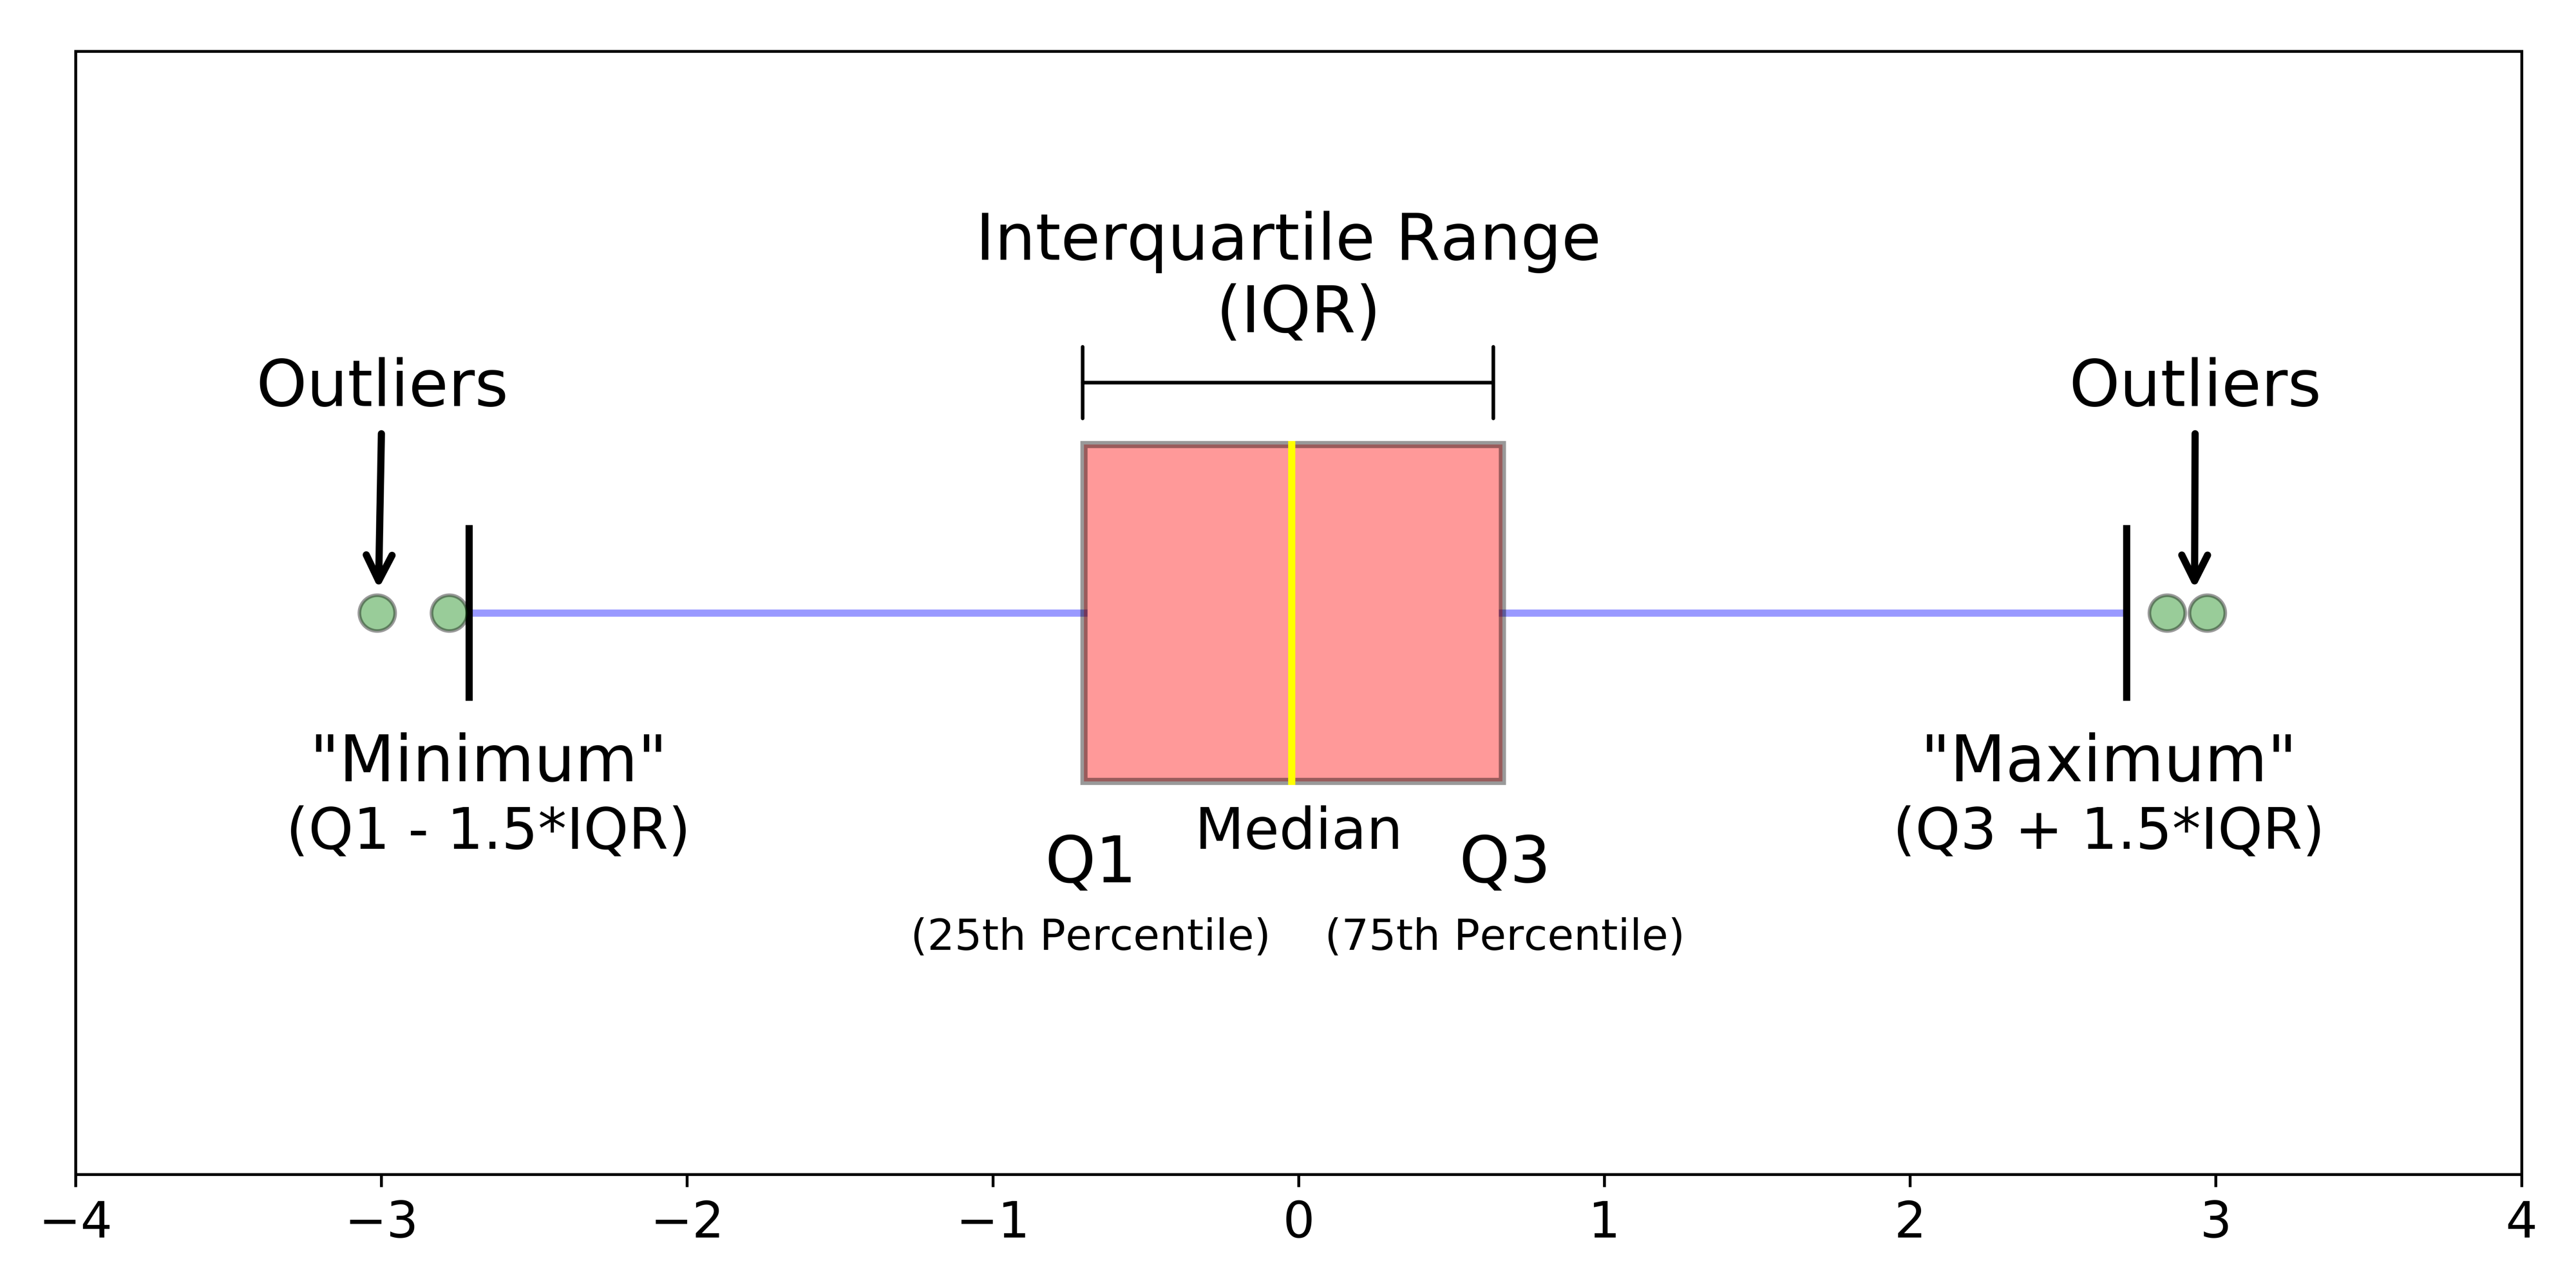

<Axes: xlabel='sex', ylabel='total_bill'>

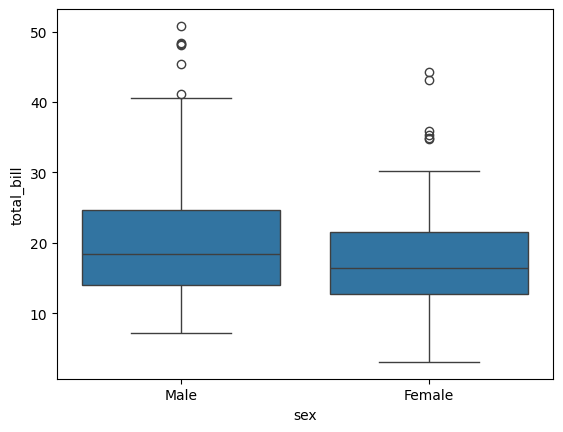

In [13]:
# box plot
sns.boxplot(data=tips , x='sex' , y='total_bill')

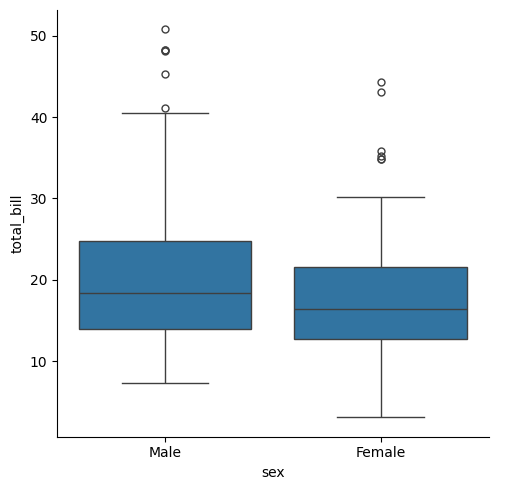

In [14]:
# using catplot
sns.catplot(data=tips , x = 'sex' , y ='total_bill' , kind='box') # fig level

<Axes: xlabel='sex', ylabel='total_bill'>

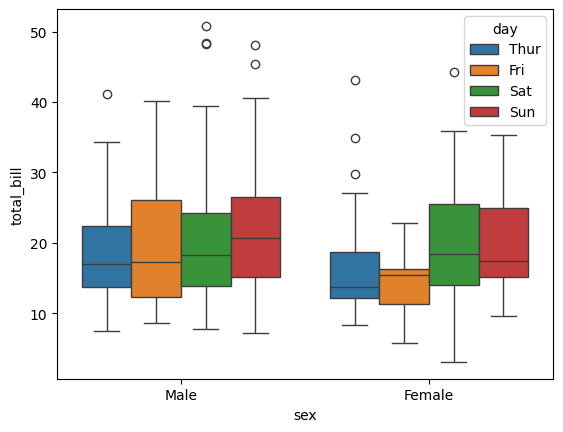

In [15]:
# hue
sns.boxplot(data=tips , x='sex' , y='total_bill' , hue='day')

<Axes: ylabel='total_bill'>

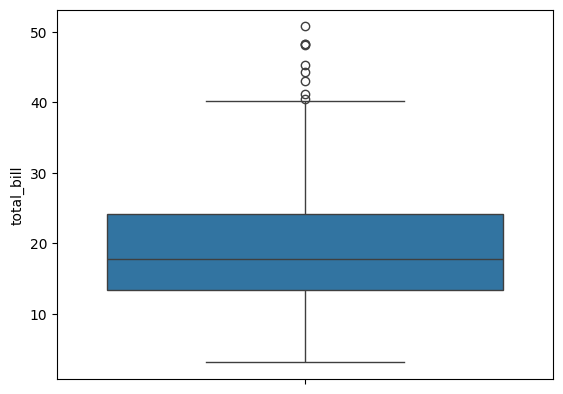

In [16]:
# single boxplot -> numerical col
sns.boxplot(data=tips , y='total_bill')

#Violinplot = (Boxplot + KDEplot)

<Axes: xlabel='day', ylabel='total_bill'>

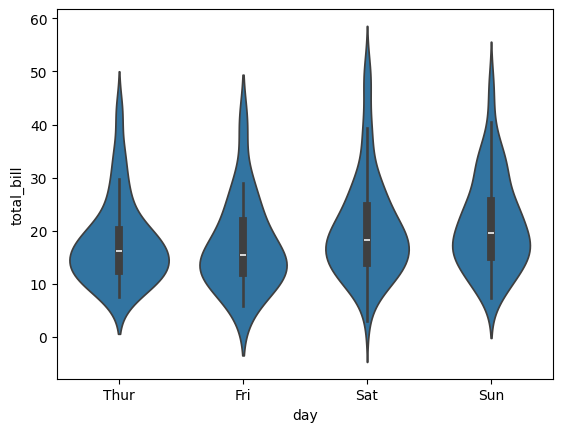

In [17]:
# violinplot
sns.violinplot(data=tips , x='day' , y='total_bill')
# as in the middle its boxplot and the structure outside looks like kde

<Axes: xlabel='day', ylabel='total_bill'>

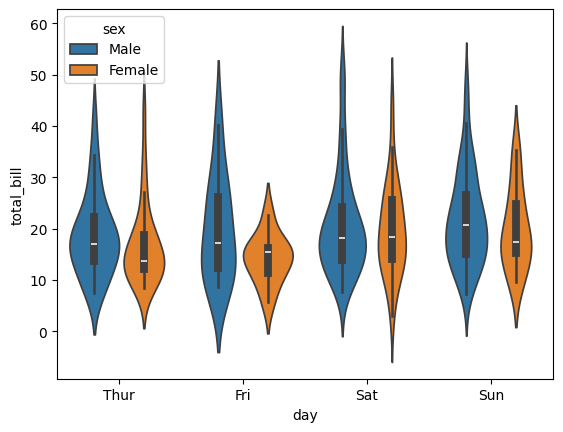

In [18]:
# hue
sns.violinplot(data=tips , x='day' , y='total_bill' , hue='sex')

<Axes: xlabel='sex', ylabel='total_bill'>

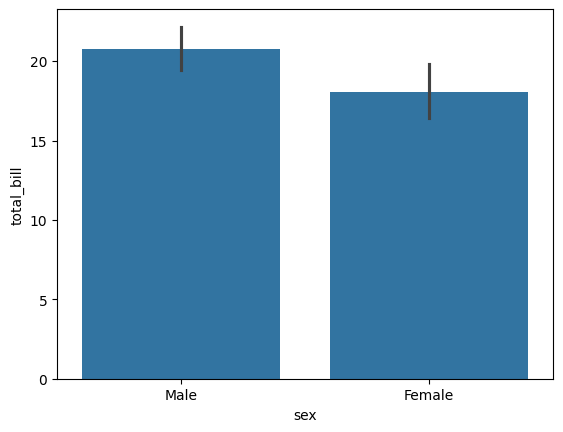

In [19]:
# barplot
sns.barplot(data=tips , x='sex' , y='total_bill')
# the black line on top is known as error bar
# and to remove these error bars we use errorbar=None

When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars

<Axes: xlabel='sex', ylabel='total_bill'>

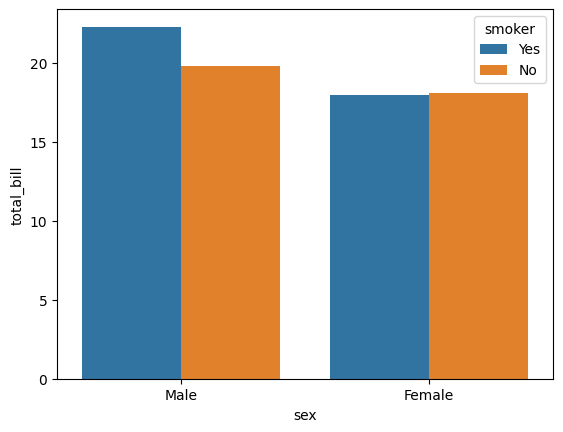

In [30]:
sns.barplot(data=tips , x='sex' , y='total_bill' , hue='smoker' , estimator='mean' , errorbar=None)

<Axes: xlabel='sex', ylabel='total_bill'>

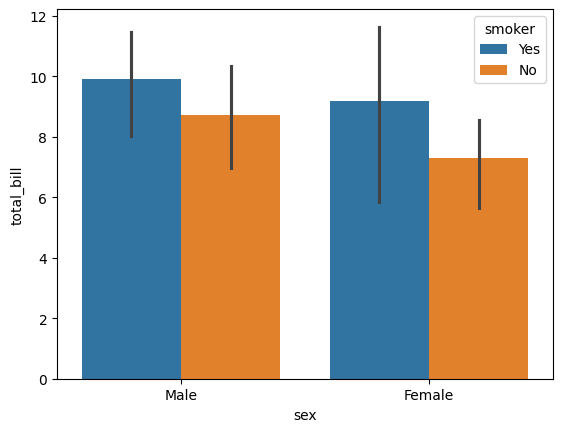

In [22]:
# by default estimator is mean but we can change that
sns.barplot(data=tips , x='sex' , y='total_bill' , hue='smoker' , estimator='std')

<Axes: xlabel='sex', ylabel='total_bill'>

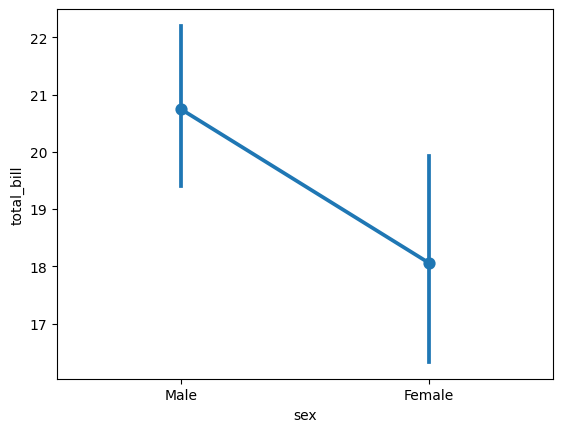

In [25]:
# point plot , brother of bar plot,bars got connected , focus on difference or comparisons
sns.pointplot(data=tips , x='sex' , y='total_bill' , estimator='mean')

<Axes: xlabel='sex', ylabel='count'>

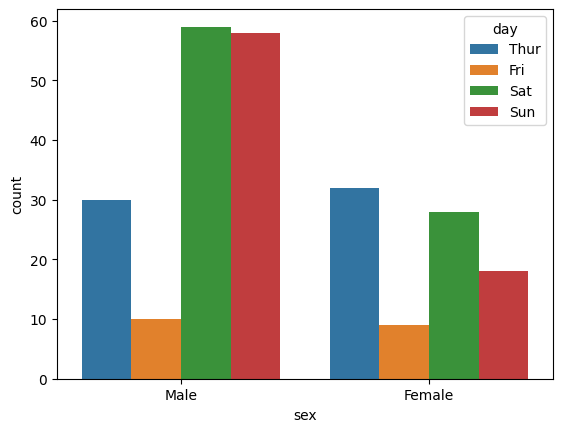

In [27]:
# countplot , only tells count for particular col
sns.countplot(data=tips,x='sex' , hue='day')

A special case for the bar plot is when you want to show the number of observations in each category rather than computing a statistic for a second variable. This is similar to a histogram over a categorical, rather than quantitative, variable

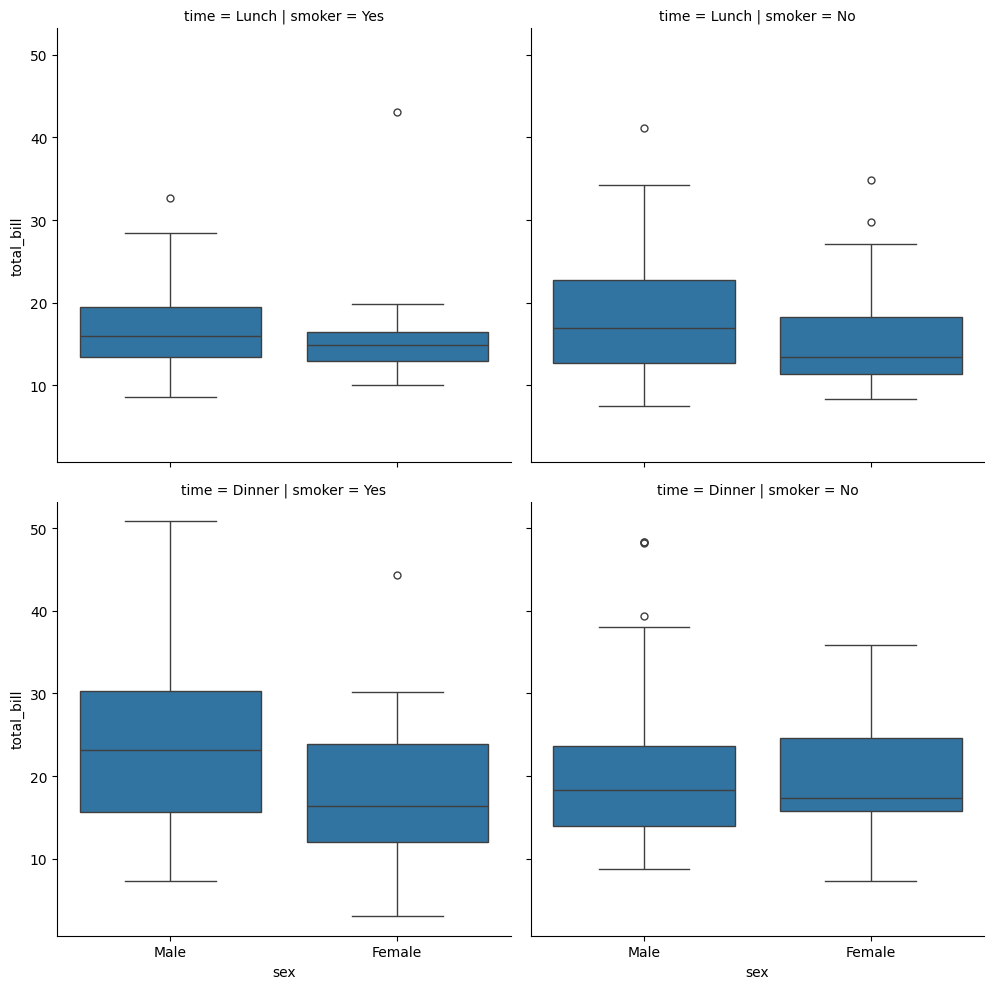

In [28]:
# faceting using catplot
sns.catplot(data=tips, x='sex',y='total_bill',col='smoker',kind='box',row='time')

### Regression Plots

- regplot
- lmplot

In the simplest invocation, both functions draw a scatterplot of two variables, x and y, and then fit the regression model y ~ x and plot the resulting regression line and a 95% confidence interval for that regression.

<Axes: xlabel='total_bill', ylabel='tip'>

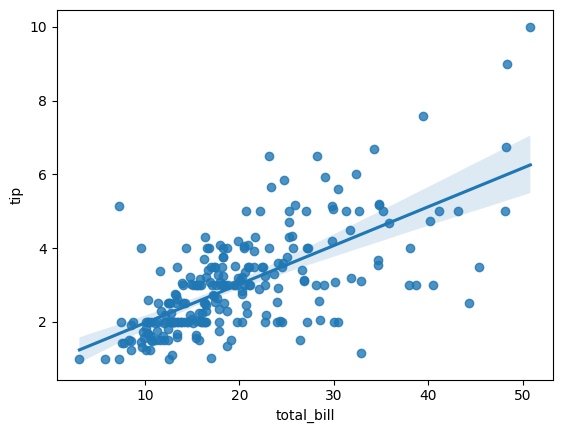

In [31]:
# axes level
# hue parameter is not available
sns.regplot(data=tips,x='total_bill',y='tip')

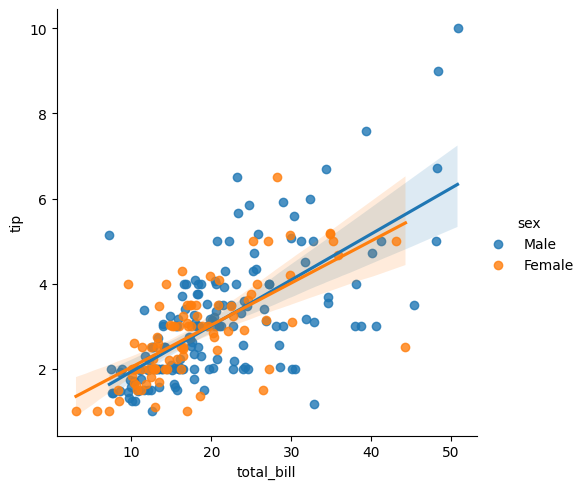

In [32]:
sns.lmplot(data=tips,x='total_bill',y='tip' , hue='sex')
# hue is available here

<Axes: xlabel='total_bill', ylabel='tip'>

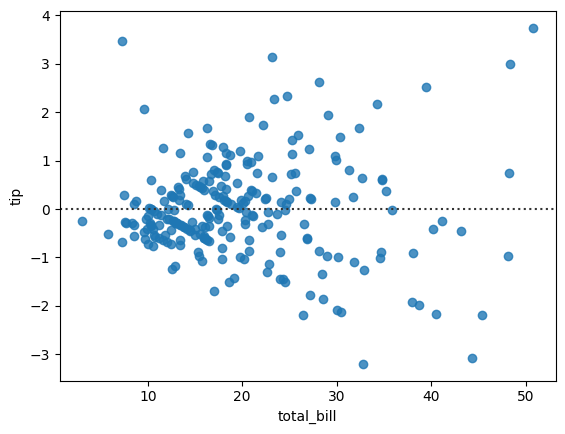

In [33]:
# residplot , plot prediction error for every point basically residual
sns.residplot(data=tips,x='total_bill',y='tip')

### A second way to plot Facet plots -> FacetGrid

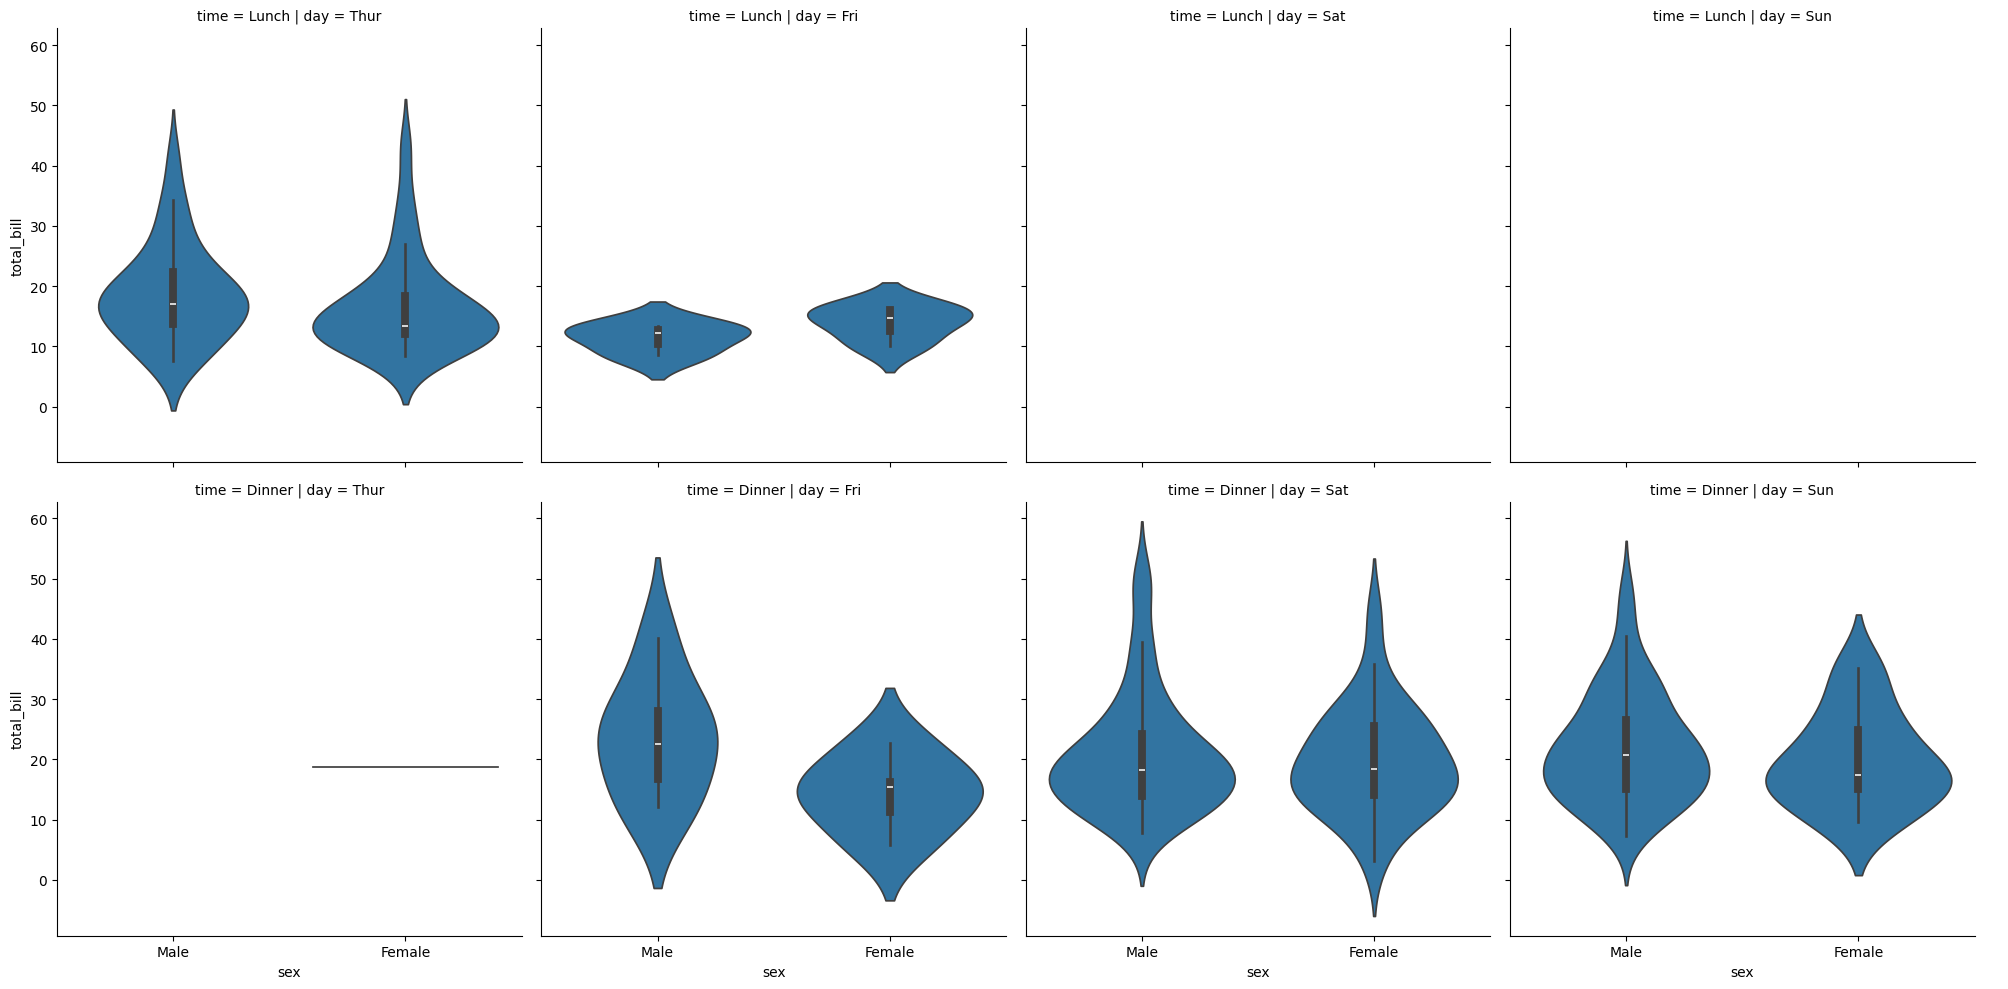

In [34]:
# figure level functions -> relplot , displot , catplot , lmplot
sns.catplot(data=tips,x='sex',y='total_bill',kind='violin',col='day',row='time')
# mostly this one is used

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


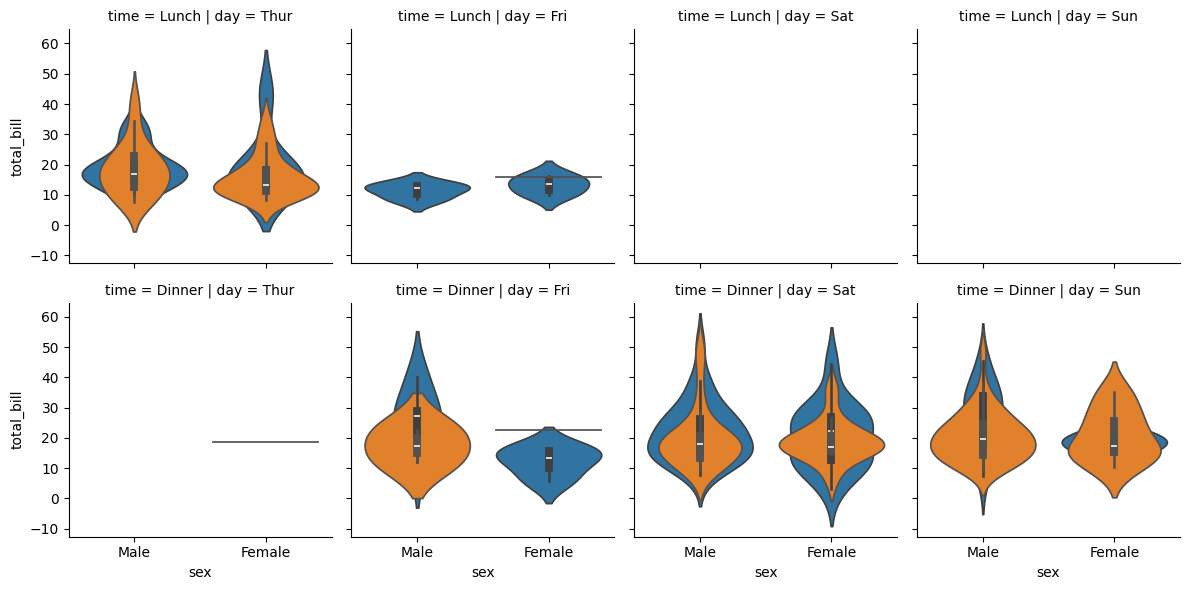

In [37]:
# same above using facet grid
g = sns.FacetGrid(data=tips,col='day',row='time')
g.map(sns.violinplot,'sex','total_bill')

### Plotting Pairwise Relationship(PairGrid vs Pairplot)

In [38]:
iris.head()
# pairplot automatically detects the numerical col of the dataset and then plot grapgh between them

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


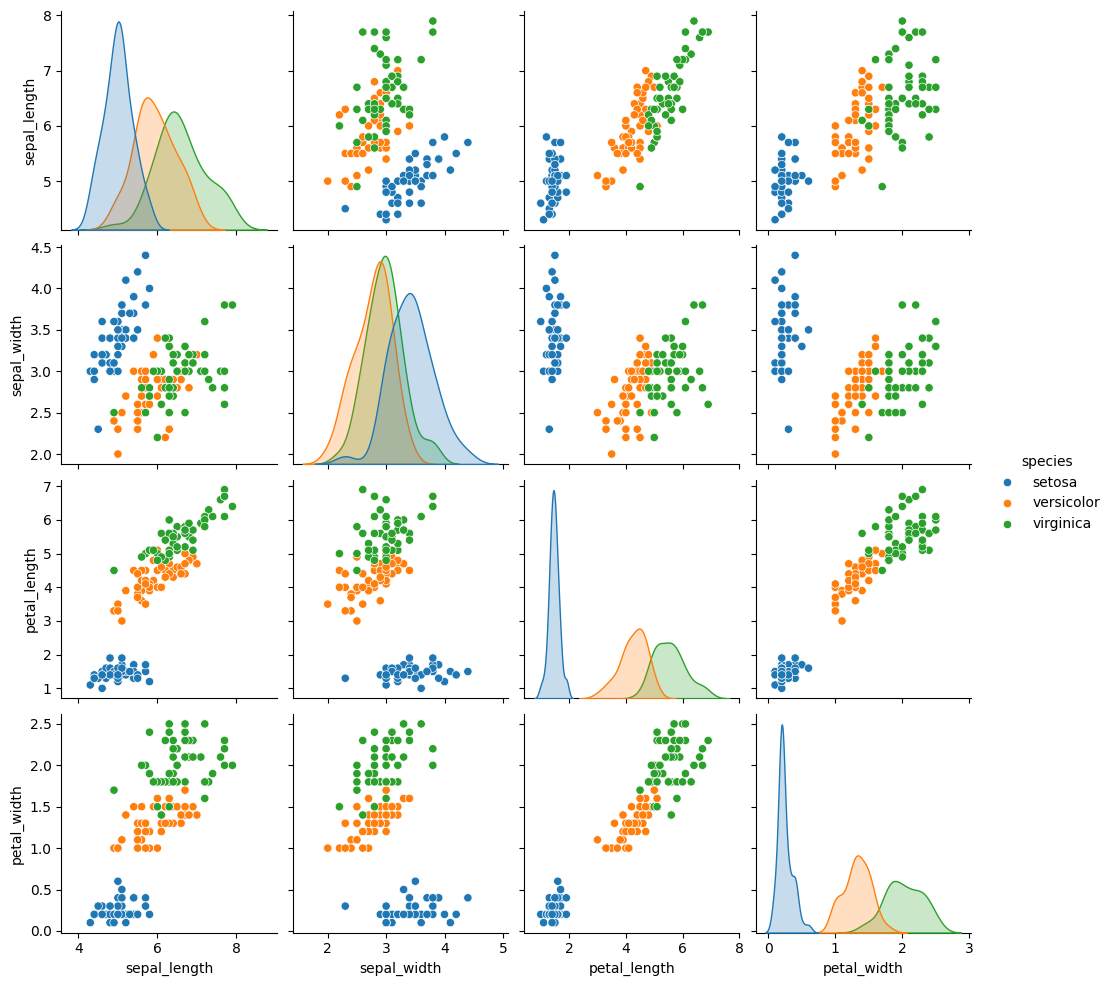

In [40]:
sns.pairplot(data=iris , hue='species')

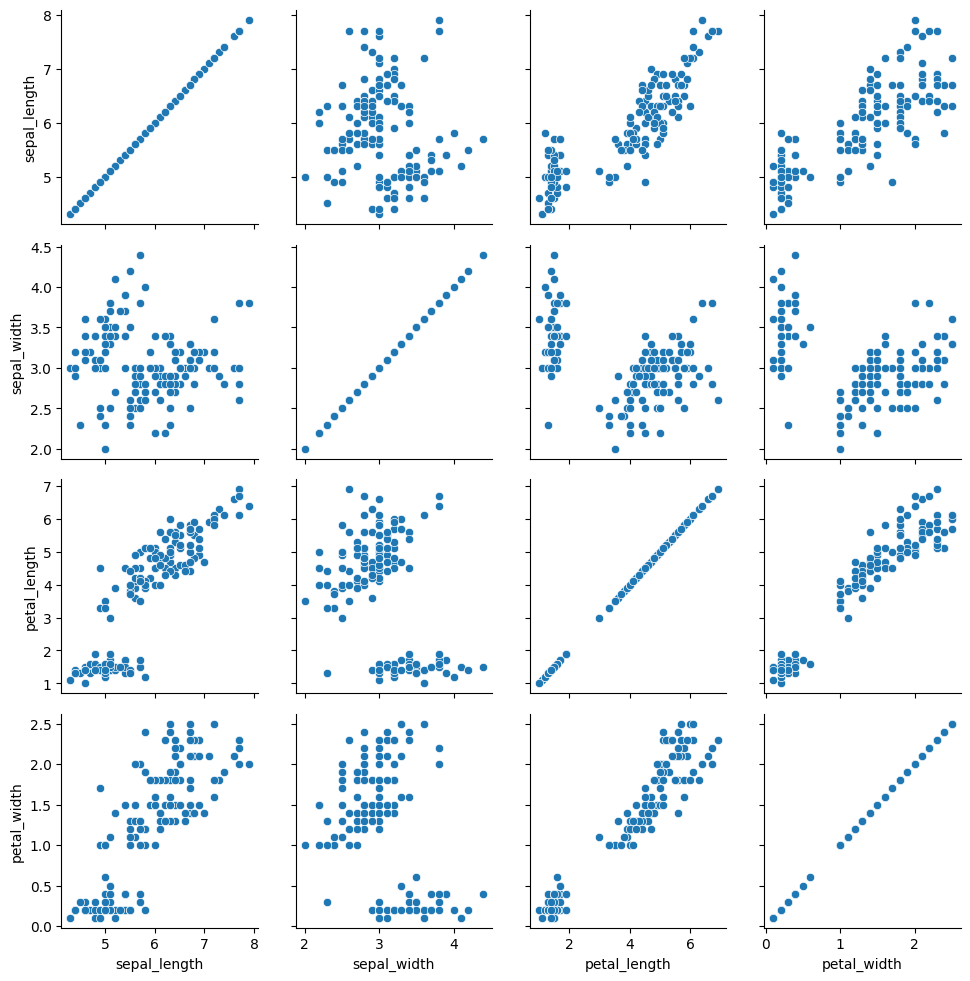

In [41]:
 # pair-grid
g = sns.PairGrid(data=iris)

# g.map
g.map(sns.scatterplot)

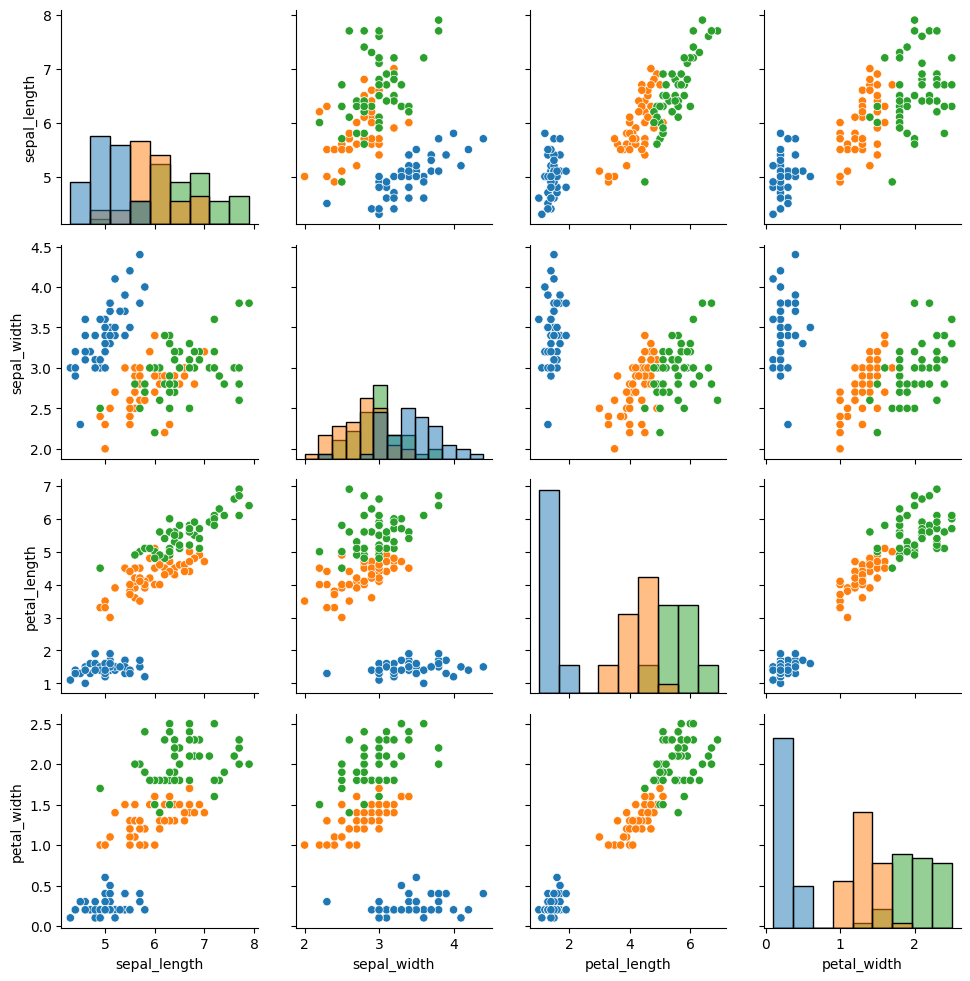

In [43]:
# map_diag -> map_offdiag
g = sns.PairGrid(data=iris , hue='species')
g.map_diag(sns.histplot) # diagonal ele as hisogram
g.map_offdiag(sns.scatterplot) # non diagonal as scatter plot
# same as first we draw but now we can add hue parameter
# pairplot is special case of parigrid
# pairgrid have more functionality

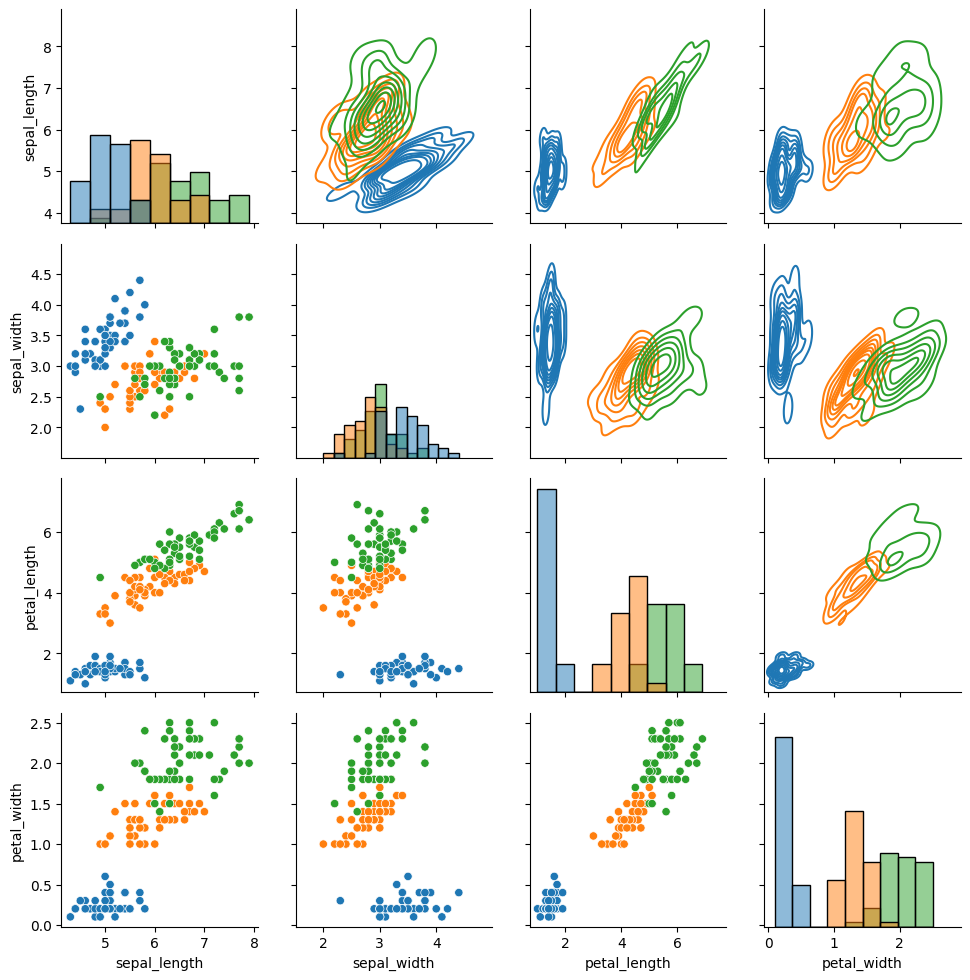

In [44]:
# map_diag -> map_upper -> map_lower
g = sns.PairGrid(data=iris , hue='species')
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)
# diagonal upper and lower both having diff graphs

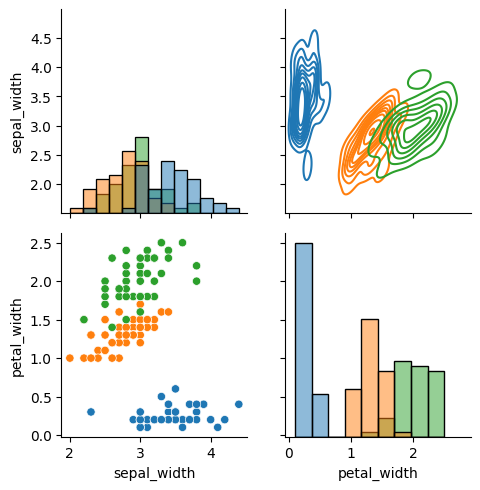

In [45]:
# vars
g = sns.PairGrid(data=iris , hue='species' , vars=['sepal_width' , 'petal_width'])
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)
# only sepal and petal used now

# JointGrid vs Jointplot

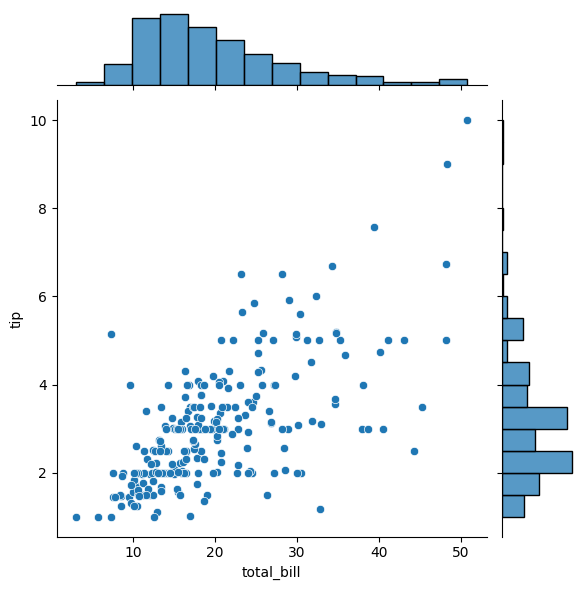

In [46]:
sns.jointplot(data=tips , x='total_bill' , y='tip' )
# by default kind is scatter plot

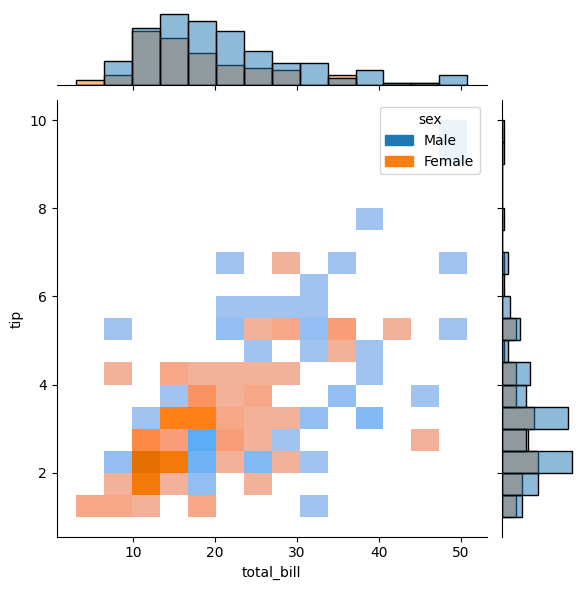

In [50]:
sns.jointplot(data=tips , x='total_bill' , y='tip' , kind='hist' ,hue='sex')

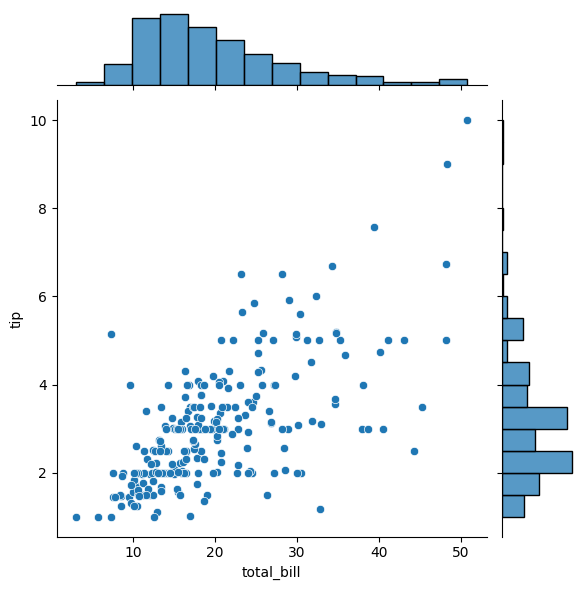

In [53]:
# same using jointgrid
g = sns.JointGrid(data=tips,x='total_bill',y='tip')
g.plot(sns.scatterplot,sns.histplot)

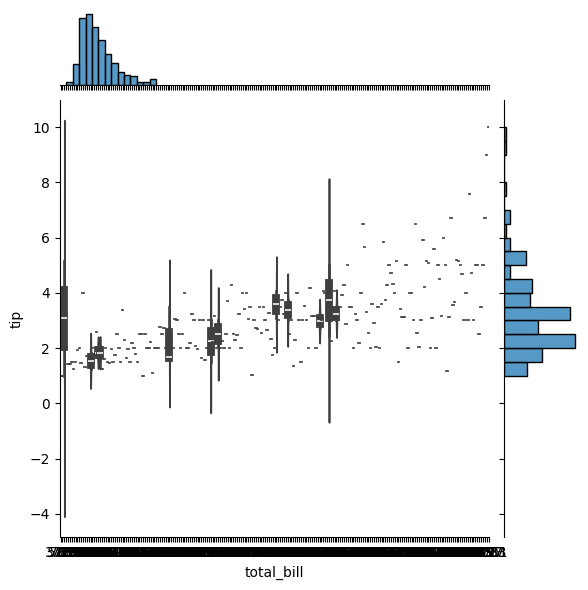

In [54]:
g = sns.JointGrid(data=tips,x='total_bill',y='tip')
g.plot(sns.violinplot,sns.histplot)
# extra graph options

# Utility Functions

In [55]:
# get dataset names
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']